## EE 587 Introduction to Robotics Homework #2
### instructor: Prof. Dr. Afşar SARANLI

### Çağdaş Güven

#### video link : https://youtu.be/U5ONaYWZyP0

1. Consider the rotation matrix R $\in$ SO(3) given by

$$
 R = \begin{bmatrix}
 \frac{1}{\sqrt{2}} & 0 & \frac{1}{\sqrt{2}} \\
 \frac{-1}{2} & \frac{1}{\sqrt{2}} & \frac{1}{2} \\
  \frac{-1}{2} & \frac{-1}{\sqrt{2}} & \frac{1}{2} 
  \end{bmatrix} 
$$

a. Determine a unit vector 𝑤 that defines the axis of rotation and the angle 𝜃 (in 
degrees) of rotation. 

b. s the pair (𝑤,𝜃) unique?

c. Determine the Euler Parameters $ \epsilon_{1}, \epsilon_{2},\epsilon_{3},\epsilon_{4},$ of 𝑅. 

Answer:

a. According to Mark W. Spong, Seth Hutchinson, M. Vidyasagar - Robot Modeling and Control 

$\theta = \cos^{-1}(\frac{r_{11}+r_{22}+r_{33}-1}{2})   = \cos^{-1}(\frac{\frac{1}{\sqrt{2}}+\frac{1}{\sqrt{2}}+\frac{1}{2}-1}{2}) = 1.0961 rad = 62.77 deg$

$$ 
k = \frac{1}{2sin\theta} \begin{bmatrix} r_{32}-r_{23} \\ 
                                            r_{13}-r_{31} \\ 
                                            r_{21}-r_{12} 
                            \end{bmatrix} 
= 
\frac{1}{2sin(1.0961)}  \begin{bmatrix} \frac{-1}{\sqrt{2}}-\frac{1}{2} \\ 
                                        \frac{1}{\sqrt{2}}-\frac{-1}{2} \\ 
                                        \frac{-1}{2}-0 
                        \end{bmatrix} 
                        
                        = 
                        
                        \begin{bmatrix} -0.6786 \\ 0.6786 \\ -0.2811 \end{bmatrix} 
                        
$$

b. The axis-angle representation is not unique since a rotation of −θ about −k is the same as a rotation of θ about k

c.  
$$
    \epsilon_{1} = cos(\frac{\theta}{2}),
    \epsilon_{2} = k_{x}sin(\frac{\theta}{2}),
    \epsilon_{3} = k_{y}sin(\frac{\theta}{2}),
    \epsilon_{4} = k_{z}sin(\frac{\theta}{2})
$$

$$
\epsilon_{1} = 0.8535
\epsilon_{2} = -0.3536
\epsilon_{3} = 0.3536
\epsilon_{4} = -0.1465
$$

2. In our case, for a rotation matrix 𝑅, we had Det(𝑅)=+1. Research and explain what 
is the meaning of a negative determinant. Cite your sources. 

### **Determinant of a Rotation Matrix and Its Meaning**

A **rotation matrix** $ R \in \text{SO}(3) $ is a special orthogonal matrix used to describe rotations in 3D space. Such matrices satisfy the following properties:

1. $ R R^\top = I $ (orthogonality condition).
2. $ \det(R) = +1 $ (special orthogonality condition).

#### **Determinant $ \det(R) = +1 $**

When $ \det(R) = +1 $, the matrix represents a **pure rotation** without any reflection. This means $ R $ describes a proper orthogonal transformation, preserving orientation and the "right-handedness" of the coordinate system.

#### **Determinant $ \det(R) = -1 $**

If $ \det(R) = -1 $, the matrix represents an **improper rotation**, which includes both:

1. A rotation.
2. A **reflection** (inversion or mirror symmetry).

This type of transformation flips the handedness of the coordinate system, turning a "right-handed" system into a "left-handed" one. It does not belong to $ \text{SO}(3) $; instead, it is part of the group $ \text{O}(3) $, which includes both proper rotations and improper orthogonal transformations.

#### **Physical Meaning of $ \det(R) = -1 $**

1. **Reflection Transformation:**
   - When $ \det(R) = -1 $, it indicates a reflection along with a rotation. A reflection reverses the direction of one axis relative to the others, leading to an inverted coordinate system.

2. **Handedness Change:**
   - A proper rotation with $ \det(R) = +1 $ preserves the handedness of the coordinate system (e.g., the right-hand rule remains intact).
   - A reflection, as indicated by $ \det(R) = -1 $, changes the handedness, making it a left-handed system.

3. **Applications:**
   - Such matrices are used in computer graphics and physics to model scenarios where reflection is involved, such as mirroring an object across a plane.

#### **References**

1. **Spong, M.W., Hutchinson, S., and Vidyasagar, M. (2020). _Robot Modeling and Control._ Wiley.**
   - According to Spong et al., a proper rotation matrix satisfies $ R \in \text{SO}(3) $, where $ \det(R) = +1 $. A determinant of $ -1 $ indicates an improper orthogonal transformation, which includes reflection and does not preserve orientation.

2. **Murray, R.M., Li, Z., and Sastry, S.S. (1994). _A Mathematical Introduction to Robotic Manipulation._ CRC Press.**
   - Murray et al. emphasize that $ \text{SO}(3) $ rotations preserve the handedness of the coordinate system, whereas $ \text{O}(3) \setminus \text{SO}(3) $ transforms invert it. 

3. For the 3-dimensional rotation about the vector [2,3,4] by 0.5 radians, compute an 
𝑆𝑂(3) rotation matrix 𝑅 using  

a. python the matrix exponential functions 'scipy.linalg.expm' and 'trexp',

b. Rodriges' rotation formula (code this yourself), and

c. the toolbox function 'angvec2tr'. Verify that you have the same result in each case.

d. Compute the equivalent unit quaternion.

In [1]:
import numpy as np
import scipy.linalg
from scipy.linalg import expm
import roboticstoolbox as rtb
from roboticstoolbox import *
from spatialmath import *
from spatialmath.base import *
from spatialgeometry import Sphere
from swift import Swift
from spatialmath import SE3
from roboticstoolbox import quintic, trapezoidal, mtraj, mstraj, xplot, ctraj
from mpl_toolkits.mplot3d import Axes3D
import math
from math import pi
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.animation import FuncAnimation
np.set_printoptions(linewidth=100, formatter={'float': lambda x: f"{x:8.4g}" if abs(x) > 1e-10 else f"{0:8.4g}"})

%matplotlib widget

In [2]:
# Defining the rotation axis and the angle of rotation
axis = np.array([2,3,4])
theta = 0.5

# Normalizing the axis vector
axis = axis /np.linalg.norm(axis)

# Defining the skew-symmetric matrix for rotation axis

skew_sym_matrix = np.array([
    [0, -axis[2], axis[1]],
    [axis[2], 0, -axis[0]],
    [-axis[1], axis[0], 0]
])

# Computing the rotation matrix using matrix exponential version

R_expm = expm(skew_sym_matrix * theta)

print(R_expm)

# Computing the roration matrix using trexp version

R_trexp = trexp(skew_sym_matrix, theta)
print('\n')
print(R_trexp)

[[  0.8945  -0.3308   0.3009]
 [  0.3814   0.9156  -0.1274]
 [ -0.2333   0.2287   0.9451]]


[[  0.8945  -0.3308   0.3009]
 [  0.3814   0.9156  -0.1274]
 [ -0.2333   0.2287   0.9451]]


In [3]:
# Computing using Rodrigues' formula

# Axis and angle variables are same as before

# skew matrix is same as before

I = np.eye(3)

Rodri = I + np.sin(theta)*skew_sym_matrix + (1 - np.cos(theta)) * np.dot(skew_sym_matrix, skew_sym_matrix)

print(Rodri)

[[  0.8945  -0.3308   0.3009]
 [  0.3814   0.9156  -0.1274]
 [ -0.2333   0.2287   0.9451]]


In [4]:
# angvec2tr version

from spatialmath.base import angvec2tr

import numpy as np

# axis and rotation angle is same

# calculating the homogeneous transformation matrix


T = angvec2tr(theta, axis)

print(T)

# extracting the rotation matrix from the homogeneous transformation matrix

R = T[:3, :3]

print('\n',R)


[[  0.8945  -0.3308   0.3009        0]
 [  0.3814   0.9156  -0.1274        0]
 [ -0.2333   0.2287   0.9451        0]
 [       0        0        0        1]]

 [[  0.8945  -0.3308   0.3009]
 [  0.3814   0.9156  -0.1274]
 [ -0.2333   0.2287   0.9451]]


In [5]:
# Computing the equivalent unit quaternion

# axis and theta same

#computing scalar and vectorel part of quaternion

q0 = np.cos(theta/2)
qv = np.sin(theta/2)*axis

quaternion = np.array([q0,qv[0],qv[1],qv[2]])

print(quaternion)

[  0.9689  0.09188   0.1378   0.1838]


4. Consider the following RRP manipulator (from J.J. Craig, “Introduction to Robotics”)

![alt text](<Screenshot from 2024-11-10 19-55-40.png>)

**a.**
Sketch a manipulator schematic diagram for this manipulator. (**Note:** A 
“schematic” is composed of only frame origins, frame axes, mutual 
orthogonals, distances and angles. See lecture slide 20 on fwd. kinematics and 
think without the actual link bodies shown.) 

On your schematic, assign and show link coordinate frames {0} to {3} using 
Denavit-Hartenberg convention of the lecture.

**b.** Determine the DH parameters and fill in the following table with your values 
and indicate all nonzero values on your schematic.

Link | ai | αi | di | θi
--- | --- | --- | --- | ---
1 | 0 | $90^o$ | 0 | $\theta_1$
2 | $a_2$ | $90^o$ | $d_{2_c}$ | $\theta_2$
3 | 0 | 0 | $d_3$ | 0

![alt text](<images/WhatsApp Image 2024-11-22 at 20.58.27.jpeg>)

5. Consider again the 5DOF “RRPRR” manipulator described below. (from J.J. Craig, 
“Introduction to Robotics”) 

![alt text](images/question_5.png)

a. Draw a schematic of this manipulator, with the axes of frames {0} through 
{5} labeled. Again indicate all non-zero Denavit-Hartenberg parameters and the joint variables on your figure. Note: Draw your schematic in the position where, as far as possible, the angles 𝜃𝑖 are close to their zero positions.

b. Determine all DH parameters and fill in the following table.

Link | $a_{i} $ | $\alpha_{i}$ |  $d_{i} $ | $\theta_{i} $ 
-----|---------|-----------|-----------|-----------|
1 | 0 | $\alpha_1$ | 0 | $\theta_{1} $
2 | $a_2$ | $\alpha_2$ | 0 | $\theta_{2} $
3 | $a_3$ | $\alpha_3$ | $d_3$ | $\theta_{3_{c}} $
4 | $a_4$ | 0 | $d_{4_{c}}$ | $\theta_{4} $
5 | $a_5$ | 0 | $d_{5_{c}}$ | $\theta_{5} $

![alt text](<images/WhatsApp Image 2024-11-22 at 20.58.27(1).jpeg>)


## Programming:

6. Consider the Peter Corke’s Robotics Toolbox for python again. In your toolbox 
installation, study and execute the kinematics tutorial given in   

https://github.com/petercorke/robotics-toolbox-python/blob/master/notebooks/kinematics.ipynb 

(Note: There are many other Jupyter notebooks in this folder that may be useful later)

7. In this question, you will use what you have learned in to construct a Puma 560 robot 
simulation where the robot end-effector will trace a 45° tilted “space circle” within 
the robot reachable workspace. You need to show an animation of the robot executing 
this motion by solving for the inverse kinematics using the toolbox. Here is a sketch 
of possible steps: 

a. Create and show a Puma 560 robot using the toolbox functions, 

b. Create a set of 50-100 points on a circle on the 𝑥𝑦 plane using equations of a 
circle, 

c. Transform these points using the spatial math toolbox functions to translate 
and rotate to a suitable location in the Puma 560 robot workspace.  

d. Show these points in the robot workspace and adjust your homogeneous 
transformation to adjust the location. You may also need a “scaling” to grow 
or shrink the circle so as to fit the robot workspace. 

e. How can you make sure that all points of the circle are within the reachable 
workspace? 

f. Solve the inverse kinematics problem for the sequence of circle points to 
determine a trajectory for all the joints of the robot. The robot end-effector 
approach vector can be in the plane or orthogonal to the plane of the circle. 

g. Using python matplotlib and pyplot functions, plot the 6 joint trajectories 
versus point index. 

h. Animate the robot so that the motion is shown.  

i. Capture the animated motion as a video, upload to YouTube as an unlisted 
video. Share the link in your report. 

In [6]:
# a. Create Puma 560 robot 

puma = rtb.models.DH.Puma560()
puma_viz = rtb.models.Puma560()

In [7]:
# b. Create circle points

t = np.linspace(0, 2*np.pi,100)

radius = 0.1

circle_points = np.array([
    radius * np.cos(t),
    radius * np.sin(t),
    np.zeros_like(t)
]).T

In [8]:
# c. Transform circle to desired pose

T = SE3.Tx(0.55) * SE3.Tz(0.5) * SE3.Ry(np.pi/2) * SE3.Ty(-0.1)
transformed_points = np.array([T * p for p in circle_points])

In [9]:
# d. Visualize points and robot
# Initialize Swift environment
# swift opens in browser
import time
env = Swift()
env.launch()

# Add robot to the environment
env.add(puma_viz)

# Add circle points to the environment
for point in transformed_points:
    env.add(Sphere(radius=0.01, pose=SE3(point), color=[1, 0, 0]))  # Red spheres for points

# Keep the visualization open
time.sleep(10)
env.close()


In [10]:
#  e. Check workspace (point should be within ~0.8m from base)

distances = np.linalg.norm(transformed_points, axis=1)
print(f"Max distance from base: {np.max(distances)}m")

Max distance from base: 0.8212485551550587m


In [11]:
# f. Solve inverse kinematics
qt = []
for point in transformed_points:
    # Define the desired end-effector pose
    T_desired = SE3(point) * SE3.Ry(90, 'deg')  # Ensure the end-effector is oriented correctly
    # Solve inverse kinematics
    sol = puma_viz.ikine_LM(T_desired)
    if sol.success:
        qt.append(sol.q)
    else:
        print("IK solution not found for point:", point)
qt = np.array(qt)

Text(0, 0.5, 'Joint angle (rad)')

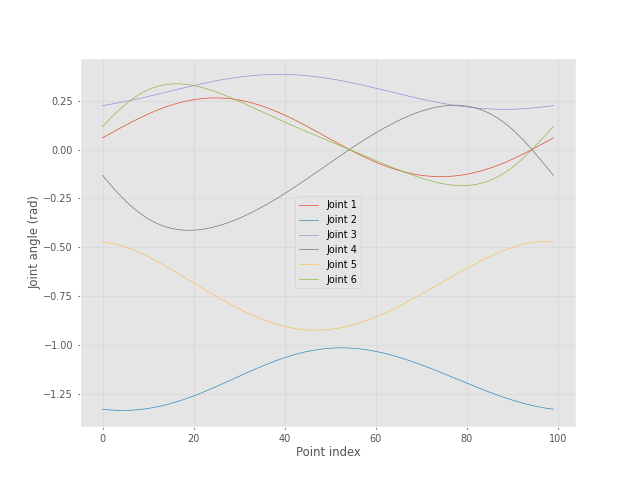

In [12]:
# g. Plot joint trajectories 
plt.figure()
for i in range(6):
    plt.plot(qt[:,i],label=f'Joint {i+1}')
plt.legend()
plt.xlabel('Point index')
plt.ylabel('Joint angle (rad)')

In [15]:
# h. Animate robot
# swift opens in browser
env =Swift()
env.launch(realtime=True)
time.sleep(10)
env.add(puma_viz)
# Add circle points to the environment
for point in transformed_points:
    env.add(Sphere(radius=0.01, pose=SE3(point), color=[1, 0, 0]))  # Red spheres for points
for q in qt:

    puma_viz.q = q
    env.step(0.1)

# Keep the visualization open
time.sleep(3)
env.close()
    